In [25]:
import os
from dotenv import load_dotenv

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [26]:
from langchain_tavily import TavilySearch

tool = TavilySearch(api_key=TAVILY_API_KEY, max_results=3)
tools = [tool]
tool.invoke("What's a node in LangGraph?")

{'query': "What's a node in LangGraph?",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'Nodes: In LangGraph, nodesrepresent individual components or agents within an AI workflow. Nodes can be thought of as “actors” that interact with each',
   'score': 0.92260116,
   'raw_content': None},
  {'url': 'https://langchain-ai.github.io/langgraph/concepts/low_level/',
   'title': 'state graph node - Overview',
   'content': 'In LangGraph, nodes arePython functions(either synchronous or asynchronous) that accept the following arguments: state : The state of the graph; config : A',
   'score': 0.8858788,
   'raw_content': None},
  {'url': 'https://www.ionio.ai/blog/a-comprehensive-guide-about-langgraph-code-included',
   'title': 'A Comprehensive Guide About Langgraph: Code Included',
   'content': 'A node can beany function or tool your agent uses in langgraphand t

In [27]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


In [ ]:
import os
import httpx
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

BASE_URL = os.getenv("OPENAI_BASE_URL")
API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("OPENAI_MODEL")

transport = httpx.HTTPTransport(verify=False)
http_client = httpx.Client(transport=transport)

llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
    model=MODEL,
    http_client=http_client,
    streaming=True
)


In [29]:
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

In [ ]:
import json

from langchain_core.messages import ToolMessage

class BasicToolNode:
    """一个根据消息调用工具的节点"""
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs:dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"]
                )
            )
        return {"messages": outputs}
    
tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [31]:
def route_tools(
        state: State,
):
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No message found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END



In [32]:
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", END: END},
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

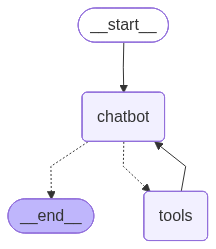

In [33]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [34]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: Here are some of the top football news stories for today (June 5, 2024):

### **1. Euro 2024 Warm-Up Matches**  
   - **Germany vs. Ukraine (0-0)** – Hosts Germany were held to a goalless draw in a pre-tournament friendly, raising questions about their attacking form.  
   - **Portugal vs. Finland (4-2)** – Cristiano Ronaldo was rested, but Gonçalo Ramos scored twice in a comfortable win.  

### **2. Brazil’s Copa América Preparations**  
   - Brazil played a friendly against Mexico (3-2 win) with young stars like Endrick (17) scoring again. Vinícius Jr. also impressed ahead of the tournament.  

### **3. Transfer News**  
   - **Kylian Mbappé to Real Madrid** – The deal is now official, with Mbappé signing a 5-year contract after leaving PSG as a free agent.  
   - **Manchester United Eyeing Defenders** – Links to Jarrad Branthwaite (Everton) and Matthijs de Ligt (Bayern Munich) are heating up.  

### **4. Manager Updates**  
   - **Chelsea’s New Manager** – Enzo Maresca (e

In [44]:
# 整合版
import os
import httpx
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv(override=True)

BASE_URL = os.getenv("OPENAI_BASE_URL")
API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("OPENAI_MODEL")

transport = httpx.HTTPTransport(verify=False)
http_client = httpx.Client(transport=transport)

llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
    model=MODEL,
    http_client=http_client,
    streaming=False
)

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearch(max_results=2)
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: 
Assistant: {"query": "2025 football news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nfl.com/news/", "title": "Latest NFL Football News", "content": "### Falcons cut K Younghoe Koo after seven years with team; sign new starter Parker Romo to two-year deal\n\nSep 19, 2025\n\n### Commanders QB Jayden Daniels (knee) ruled out for Sunday vs. Raiders; Marcus Mariota to start\n\nSep 19, 2025 ruled out for Sunday vs. Raiders; Marcus Mariota to start\")\n\n### NFL news roundup: Buccaneers' Emeka Egbuka (hip/groin) returns to practice, questionable vs. Jets\n\nSep 19, 2025 returns to practice, questionable vs. Jets\") [...] Skip to main content\n\n# Latest NFL News\n\n## Latest News\n\n### Niners QB Brock Purdy (shoulder/toe; questionable) unlikely to serve as starter Sunday vs. Cardinals\n\nSep 19, 2025 unlikely to serve as starter Sunday vs. Cardinals\")\n\n### Xavier Worthy (shoulder) questionable to play vs. Giants as Chiefs look